## E4


### Mision 1: diagnostico de los datos

Primero cargamos el archivo y revisamos su estructura general antes de modificarlo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('data/E4_data.csv')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [2]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790.000000,8790,8790,8790
unique,8790,2,8787,4528,86,1713,NaN,14,220,513
top,s1,Movie,9-Feb,Not Given,United States,1/1/2020,NaN,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,NaN,3205,1791,362
mean,NaN,NaN,NaN,NaN,NaN,NaN,2014.183163,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,8.825466,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN


Ademas de los NaN, si nos fijamos, en este archivo existen valores como Not Given, que para efectos del ejercicio consideramos que funcionan como informacion faltante aunque no sean reconocidos automaticamente por pandas.

In [3]:
diagnostico_faltantes = pd.DataFrame({
    'faltantes_NaN': df.isna().sum(),
    'valores_Not_Given': (df == 'Not Given').sum(),
    'valores_unicos': df.nunique()
})

diagnostico_faltantes

,faltantes_NaN,valores_Not_Given,valores_unicos
show_id,0,0,8790
type,0,0,2
title,0,0,8787
director,0,2588,4528
country,0,287,86
date_added,0,0,1713
release_year,0,0,74
rating,0,0,14
duration,0,0,220
listed_in,0,0,513


In [4]:
duplicados = pd.DataFrame({
    'criterio': ['fila completa', 'show_id', 'title_type_release_year'],
    'duplicados': [
        df.duplicated().sum(),
        df['show_id'].duplicated().sum(),
        df.duplicated(subset=['title', 'type', 'release_year']).sum()
    ]
})

duplicados

,criterio,duplicados
0,fila completa,0
1,show_id,0
2,title_type_release_year,3


Revisamos formatos que requieren transformacion: 

- date_added esta como texto 
- duration mezcla minutos y temporadas
- listed_in contiene multiples generos en una sola celda.

In [5]:
df_diagnostico = df.copy()
df_diagnostico['date_added_parseada'] = pd.to_datetime(df_diagnostico['date_added'], errors='coerce')
df_diagnostico['duration_numero'] = df_diagnostico['duration'].str.extract(r'(\d+)').astype(float)
# extraemos mediante una 'expresión regular' la parte numérica de la duración
# (por ejemplo, 90 en '90 min') y la convertimos a float para poder realizar
# operaciones y análisis numéricos.

df_diagnostico['duration_unidad'] = df_diagnostico['duration'].str.extract(r'([A-Za-z]+)').iloc[:, 0]
# y aqui extraemos la unidad de duración formada por letras
# (por ejemplo, 'min' o 'Seasons'). str.extract() devuelve un df al utilizar
# un ese patron, por lo que seleccionamos su primera columna con iloc[:, 0].

diagnostico_formatos = pd.DataFrame({
    'fechas_no_parseadas': [df_diagnostico['date_added_parseada'].isna().sum()],
    'duraciones_no_parseadas': [df_diagnostico['duration_numero'].isna().sum()],
    'anios_minimos': [df_diagnostico['release_year'].min()],
    'anios_maximos': [df_diagnostico['release_year'].max()]
})

# si quieren ahondar, aunque no sea estrictamente necesario, https://docs.python.org/3/library/re.html
diagnostico_formatos

,fechas_no_parseadas,duraciones_no_parseadas,anios_minimos,anios_maximos
0,0,0,1925,2021


La idea ahora es ver si hay anomalias:
- que sea movie y que la unidad de duracion no sea minutos
- o que sea tv show y que la unidad de duracion no sea temporadas

In [6]:
anomalias_duracion = df_diagnostico[
    ((df_diagnostico['type'] == 'Movie') & 
     (df_diagnostico['duration_unidad'].ne('min'))) |
    
    ((df_diagnostico['type'] == 'TV Show') & 
     (~df_diagnostico['duration_unidad'].isin(['Season', 'Seasons'])))
]

# ne y eq son metodos de pandas que permiten hacer comparaciones de manera vectorizada.
# ne es not equal, es decir, !=, asi como eq es equal, es decir, ==.

print(f'Cantidad de anomalias de duracion: {len(anomalias_duracion)}')
anomalias_duracion[['show_id', 'type', 'title', 'duration']].head()

Cantidad de anomalias de duracion: 0


,show_id,type,title,duration


Como no se detectan inconsistencias entre type y duration, revisamos otros posibles valores atipicos. 

Estos casos no necesariamente son errores, pero pueden influir en promedios, conteos o interpretaciones posteriores.

In [7]:
anio_minimo_catalogo = 2008 # nos fijamos en 2008 que en Misión 5 dice "utilice 2008 como la
# primera fecha posible de incorporacion."

anio_incorporacion_anterior_2008 = df_diagnostico[
    df_diagnostico['date_added_parseada'].dt.year < anio_minimo_catalogo
]

estreno_posterior_a_incorporacion = df_diagnostico[
    df_diagnostico['release_year'] > df_diagnostico['date_added_parseada'].dt.year
]

peliculas_duracion_extrema = df_diagnostico[ # igual es posible que hayan cortos de menos de 20 o pelis de mas de 280 min, pero son casos atipicos 
    # que pueden influir en promedios o interpretaciones posteriores.
    (df_diagnostico['type'] == 'Movie') &
    ((df_diagnostico['duration_numero'] < 20) | (df_diagnostico['duration_numero'] > 280))
]

series_muy_largas = df_diagnostico[
    (df_diagnostico['type'] == 'TV Show') &
    (df_diagnostico['duration_numero'] > 15)
]

ratings_poco_frecuentes = df_diagnostico['rating'].value_counts()[lambda s: s < 10]

resumen_atipicos = pd.DataFrame({
    'revision': [
        'date_added antes de 2008',
        'release_year posterior a year_added',
        'peliculas con duracion < 20 o > 280 min',
        'series con mas de 15 temporadas',
        'ratings con menos de 10 registros'
    ],
    'cantidad': [
        len(anio_incorporacion_anterior_2008),
        len(estreno_posterior_a_incorporacion),
        len(peliculas_duracion_extrema),
        len(series_muy_largas),
        len(ratings_poco_frecuentes)
    ]
})

resumen_atipicos

,revision,cantidad
0,date_added antes de 2008,0
1,release_year posterior a year_added,14
2,peliculas con duracion < 20 o > 280 min,27
3,series con mas de 15 temporadas,1
4,ratings con menos de 10 registros,3


In [8]:
columnas_revision = ['show_id', 'type', 'title', 'date_added', 'release_year', 'rating', 'duration']

ejemplos_atipicos = pd.concat([ # aqui hay una forma de consolidad informacion con concatenacion de dataframes y 
    # asignando una columna adicional para indicar el tipo de revision
    estreno_posterior_a_incorporacion.assign(revision='release_year posterior a year_added'),
    peliculas_duracion_extrema.assign(revision='pelicula con duracion extrema'),
    series_muy_largas.assign(revision='serie con muchas temporadas'),
    df_diagnostico[df_diagnostico['rating'].isin(ratings_poco_frecuentes.index)].assign(revision='rating poco frecuente')
])

ejemplos_atipicos[['revision'] + columnas_revision].head(15)

,revision,show_id,type,title,date_added,release_year,rating,duration
3869,release_year posterior a year_added,s5395,Movie,Hans Teeuwen: Real Rancour,7/1/2017,2018,TV-MA,86 min
5138,release_year posterior a year_added,s7064,Movie,Incoming,10/26/2018,2019,TV-MA,89 min
5178,release_year posterior a year_added,s7113,TV Show,Jack Taylor,3/31/2013,2016,TV-MA,1 Season
6948,release_year posterior a year_added,s1552,TV Show,Hilda,12/14/2020,2021,TV-Y7,2 Seasons
6992,release_year posterior a year_added,s1697,TV Show,Polly Pocket,11/15/2020,2021,TV-Y,2 Seasons
7355,release_year posterior a year_added,s2921,TV Show,Love Is Blind,2/13/2020,2021,TV-MA,1 Season
7436,release_year posterior a year_added,s3169,TV Show,Fuller House,12/6/2019,2020,TV-PG,5 Seasons
7484,release_year posterior a year_added,s3288,TV Show,Maradona in Mexico,11/13/2019,2020,TV-MA,1 Season
7517,release_year posterior a year_added,s3370,TV Show,BoJack Horseman,10/25/2019,2020,TV-MA,6 Seasons
7537,release_year posterior a year_added,s3434,TV Show,The Hook Up Plan,10/11/2019,2020,TV-MA,2 Seasons


A primera vista, no hay inconsistencias, pero luego vemos ejemplos de películas añadidas antes de su estreno oficial, películas con duraciones extremas, entre otras.

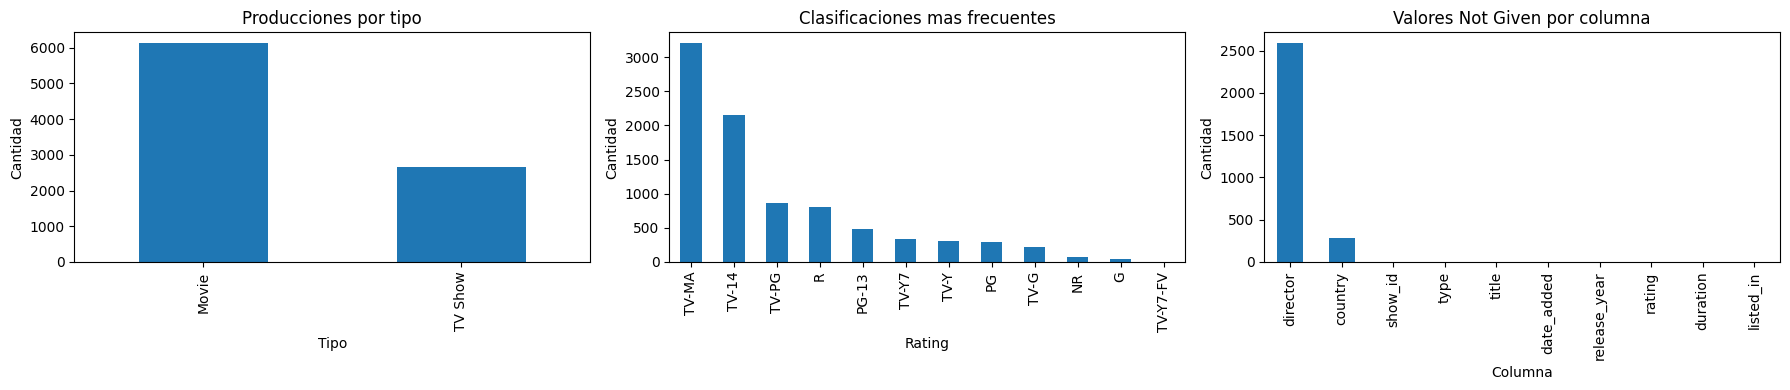

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df['type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Producciones por tipo')
axes[0].set_xlabel('Tipo')
axes[0].set_ylabel('Cantidad')

df['rating'].value_counts().head(12).plot(kind='bar', ax=axes[1])
axes[1].set_title('Clasificaciones mas frecuentes')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cantidad')

((df == 'Not Given').sum().sort_values(ascending=False)
 .plot(kind='bar', ax=axes[2]))
axes[2].set_title('Valores Not Given por columna')
axes[2].set_xlabel('Columna')
axes[2].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

No presenta duplicados por show_id ni faltantes NaN, pero director y country contienen valores Not Given. Estos casos deben tratarse como informacion incompleta. Tambien se requiere transformar date_added a fecha, separar la duracion numerica de su unidad y representar listed_in como multiples categorias, porque una misma produccion puede pertenecer a mas de un genero.

### Mision 2: diseno de la solucion

Se propone

```text
Datos originales
    |
    v
Diagnostico de calidad
    |-- faltantes semanticos: Not Given
    |-- duplicados: fila completa, show_id, titulo/tipo/anio
    |-- formatos: fecha, duracion, generos multiples
    v
Preparacion
    |-- convertir Not Given a NaN en variables informativas
    |-- eliminar duplicados solo si son equivalentes
    |-- parsear date_added
    |-- separar duracion en numero, minutos y temporadas
    |-- crear pais principal y lista de paises
    v
Representacion de generos
    |-- tabla ancha: columnas booleanas por categoria
    |-- tabla larga: show_id, categoria
    v
Validacion
    |-- conservar cantidad de show_id
    |-- no duplicar producciones
    |-- revisar tipos y rangos
    v
Consultas finales
    |-- genero dominante reciente
    |-- demora promedio de incorporacion a Netflix
    |-- evolucion de ratings en Horror
```

Los duplicados exactos se eliminan, pero no se eliminan peliculas solo por compartir titulo. 

Los valores Not Given en director y country se reemplazan por NaN y se conservan las filas, porque eliminar registros completos podria sesgar los conteos de generos, años y ratings. 

Los generos se representan con variables booleanas y con una tabla larga vinculada por show_id, ya que una produccion puede pertenecer a varias categorias simultaneamente.

### Mision 3: preparacion de los datos

Construimos una version preparada del conjunto. La idea es conservar las producciones, transformar formatos y dejar disponibles variables utiles para las consultas posteriores.

In [10]:
df_preparado = df.copy()

# faltantes semanticos
df_preparado[['director', 'country']] = df_preparado[['director', 'country']].replace('Not Given', np.nan)

# duplicados exactos y por identificador
df_preparado = df_preparado.drop_duplicates()
df_preparado = df_preparado.drop_duplicates(subset='show_id', keep='first')

# fechas
df_preparado['date_added'] = pd.to_datetime(df_preparado['date_added'], errors='coerce')
df_preparado['year_added'] = df_preparado['date_added'].dt.year
df_preparado['month_added'] = df_preparado['date_added'].dt.month

# duracion
df_preparado['duration_value'] = df_preparado['duration'].str.extract(r'(\d+)').astype(float)
df_preparado['duration_unit'] = df_preparado['duration'].str.extract(r'([A-Za-z]+)').iloc[:, 0]
df_preparado['duration_minutes'] = np.where(
    df_preparado['type'].eq('Movie'),
    df_preparado['duration_value'],
    np.nan
)
df_preparado['duration_seasons'] = np.where(
    df_preparado['type'].eq('TV Show'),
    df_preparado['duration_value'],
    np.nan
)

# paises
df_preparado['country_list'] = df_preparado['country'].apply(
    lambda x: [pais.strip() for pais in str(x).split(',')] if pd.notna(x) else []
)
df_preparado['primary_country'] = df_preparado['country_list'].apply(lambda x: x[0] if len(x) > 0 else np.nan)

# decada de estreno
df_preparado['release_decade'] = (df_preparado['release_year'] // 10) * 10

df_preparado.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_value,duration_unit,duration_minutes,duration_seasons,country_list,primary_country,release_decade
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90.0,min,90.0,NaN,[United States],United States,2020
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1.0,Season,NaN,1.0,[France],France,2020
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,1.0,Season,NaN,1.0,[United States],United States,2020
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,91.0,min,91.0,NaN,[Brazil],Brazil,2020
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,125.0,min,125.0,NaN,[United States],United States,1990


In [11]:
comparacion_preparacion = pd.DataFrame({
    'metrica': [
        'filas',
        'show_id_unicos',
        'fechas_no_parseadas',
        'director_faltante',
        'country_faltante',
        'peliculas_con_minutos',
        'series_con_temporadas'
    ],
    'original': [
        len(df),
        df['show_id'].nunique(),
        pd.to_datetime(df['date_added'], errors='coerce').isna().sum(),
        (df['director'] == 'Not Given').sum(),
        (df['country'] == 'Not Given').sum(),
        np.nan,
        np.nan
    ],
    'preparado': [
        len(df_preparado),
        df_preparado['show_id'].nunique(),
        df_preparado['date_added'].isna().sum(),
        df_preparado['director'].isna().sum(),
        df_preparado['country'].isna().sum(),
        df_preparado.loc[df_preparado['type'] == 'Movie', 'duration_minutes'].notna().sum(),
        df_preparado.loc[df_preparado['type'] == 'TV Show', 'duration_seasons'].notna().sum()
    ]
})

comparacion_preparacion

,metrica,original,preparado
0,filas,8790.0,8790
1,show_id_unicos,8790.0,8790
2,fechas_no_parseadas,0.0,0
3,director_faltante,2588.0,2588
4,country_faltante,287.0,287
5,peliculas_con_minutos,NaN,6126
6,series_con_temporadas,NaN,2664


In [12]:
filas_perdidas_si_eliminamos_faltantes = df_preparado.dropna(subset=['director', 'country']).shape[0]
impacto_eliminar = pd.DataFrame({
    'filas_preparadas': [len(df_preparado)],
    'filas_si_eliminamos_director_o_country_faltante': [filas_perdidas_si_eliminamos_faltantes],
    'filas_perdidas': [len(df_preparado) - filas_perdidas_si_eliminamos_faltantes],
    'porcentaje_perdido': [(len(df_preparado) - filas_perdidas_si_eliminamos_faltantes) / len(df_preparado)]
})

impacto_eliminar

,filas_preparadas,filas_si_eliminamos_director_o_country_faltante,filas_perdidas,porcentaje_perdido
0,8790,5915,2875,0.327076


Eliminar filas completas por no tener director o pais descartaria una parte importante del catalogo. Por eso se conservan los registros y se excluyen esos campos solo en analisis donde sean indispensables, por ejemplo al contar paises productores.

### Mision 4: representacion de generos

listed_in contiene varias etiquetas separadas por comas. Para usar las categorias pedidas se construye una representacion multietiqueta: una columna booleana por categoria en df_generos y una tabla larga generos_long con la relacion show_id--categoria.

In [13]:
categorias_objetivo = {
    'Action & Adventure': ['action & adventure'],
    'Comedy': ['comedies', 'comedy', 'stand-up comedy'],
    'Drama': ['dramas', 'drama'],
    'Horror': ['horror'],
    'Mystery': ['mysteries', 'mystery'],
    'Sci-Fi & Fantasy': ['sci-fi & fantasy'],
    'Thrillers': ['thrillers', 'thriller'],
    'Independent': ['independent'],
    'Children & Family': ['children & family', "kids' tv", 'children']
}


def normalizar_generos(texto):
    return [g.strip().lower() for g in str(texto).split(',')]


def pertenece_categoria(generos, patrones):
    return any(any(patron in genero for patron in patrones) for genero in generos)


df_generos = df_preparado.copy()
df_generos['generos_lista'] = df_generos['listed_in'].apply(normalizar_generos)

for categoria, patrones in categorias_objetivo.items():
    columna = 'genero_' + categoria.replace('&', 'and').replace(' ', '_').replace('-', '_')
    df_generos[columna] = df_generos['generos_lista'].apply(lambda generos: pertenece_categoria(generos, patrones))

columnas_genero = [c for c in df_generos.columns if c.startswith('genero_')]

generos_long = (
    df_generos[['show_id'] + columnas_genero]
    .melt(id_vars='show_id', var_name='categoria_columna', value_name='pertenece')
    .query('pertenece')
    .assign(categoria=lambda x: x['categoria_columna'].str.replace('genero_', '', regex=False).str.replace('_', ' '))
    [['show_id', 'categoria']]
)

df_generos[['show_id', 'title', 'listed_in'] + columnas_genero].head()

,show_id,title,listed_in,genero_Action_and_Adventure,genero_Comedy,genero_Drama,genero_Horror,genero_Mystery,genero_Sci_Fi_and_Fantasy,genero_Thrillers,genero_Independent,genero_Children_and_Family
0,s1,Dick Johnson Is Dead,Documentaries,False,False,False,False,False,False,False,False,False
1,s3,Ganglands,"Crime TV Shows, International TV Shows, TV Act...",True,False,False,False,False,False,False,False,False
2,s6,Midnight Mass,"TV Dramas, TV Horror, TV Mysteries",False,False,True,True,True,False,False,False,False
3,s14,Confessions of an Invisible Girl,"Children & Family Movies, Comedies",False,True,False,False,False,False,False,False,True
4,s8,Sankofa,"Dramas, Independent Movies, International Movies",False,False,True,False,False,False,False,True,False


In [14]:
validacion_generos = pd.DataFrame({
    'filas_preparado': [len(df_preparado)],
    'filas_generos': [len(df_generos)],
    'show_id_preparado': [df_preparado['show_id'].nunique()],
    'show_id_generos': [df_generos['show_id'].nunique()],
    'relaciones_show_categoria': [len(generos_long)],
    'show_id_duplicados_en_df_generos': [df_generos['show_id'].duplicated().sum()]
})

validacion_generos

,filas_preparado,filas_generos,show_id_preparado,show_id_generos,relaciones_show_categoria,show_id_duplicados_en_df_generos
0,8790,8790,8790,8790,10161,0


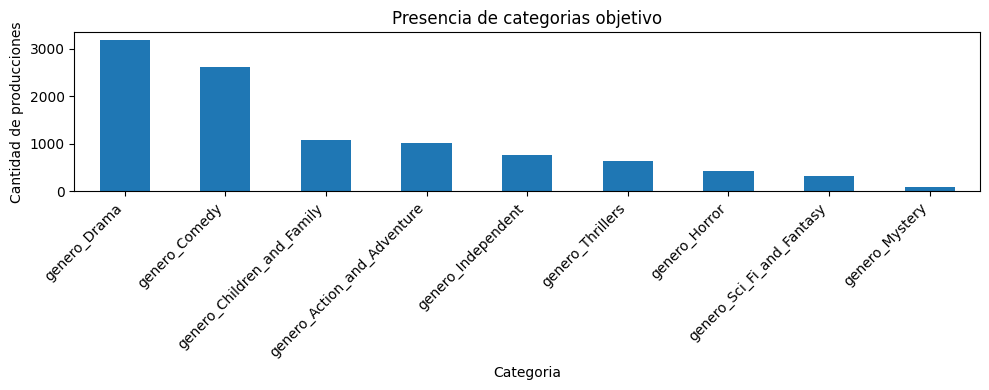

genero_Drama                   3188
genero_Comedy                  2612
genero_Children_and_Family     1089
genero_Action_and_Adventure    1026
genero_Independent              756
genero_Thrillers                634
genero_Horror                   432
genero_Sci_Fi_and_Fantasy       326
genero_Mystery                   98
dtype: int64

In [15]:
conteo_categorias = df_generos[columnas_genero].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
conteo_categorias.plot(kind='bar')
plt.title('Presencia de categorias objetivo')
plt.xlabel('Categoria')
plt.ylabel('Cantidad de producciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

conteo_categorias

Los criterios de reconocimiento usan texto en minusculas y patrones relacionados. Por ejemplo, TV Horror y Horror Movies se asignan a Horror; TV Comedies, Comedies y Stand-Up Comedy se asignan a Comedy; Kids' TV se considera relacionado con Children & Family. La relacion original con cada produccion se conserva mediante show_id.

### Mision 5: consultas

Usamos los datos preparados y la representacion multietiqueta de generos para responder las consultas finales.

#### Consulta a

Se considera como periodo reciente los ultimos cinco años de estreno disponibles en el archivo. Si el año maximo es 2021, el periodo corresponde a 2017-2021. Para el conteo por pais se consideran solo peliculas y se explota la lista de paises, contando cada pais asociado a la produccion.

In [16]:
anio_maximo = df_generos['release_year'].max()
anio_inicio = anio_maximo - 4

df_reciente = df_generos[df_generos['release_year'].between(anio_inicio, anio_maximo)]
presencia_reciente = df_reciente[columnas_genero].sum().sort_values(ascending=False)

genero_mayor_columna = presencia_reciente.index[0]
genero_mayor_nombre = genero_mayor_columna.replace('genero_', '').replace('_', ' ')

presencia_reciente

genero_Drama                   1648
genero_Comedy                  1331
genero_Children_and_Family      612
genero_Action_and_Adventure     428
genero_Independent              382
genero_Thrillers                342
genero_Horror                   239
genero_Sci_Fi_and_Fantasy       144
genero_Mystery                   81
dtype: int64

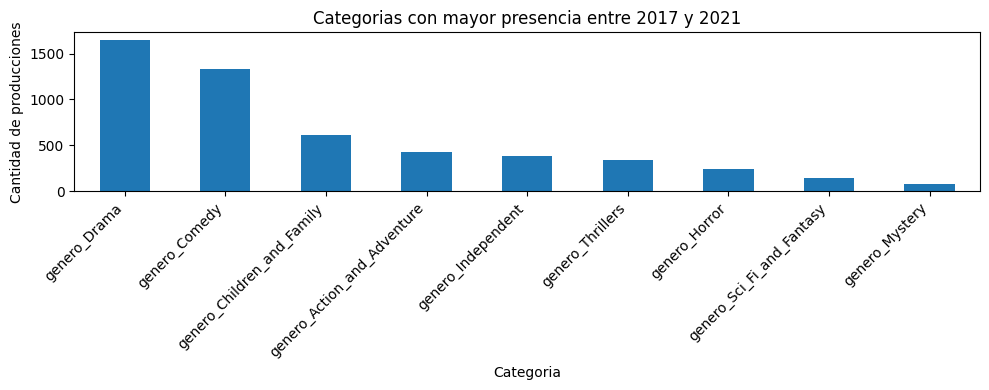

In [17]:
plt.figure(figsize=(10, 4))
presencia_reciente.plot(kind='bar')
plt.title(f'Categorias con mayor presencia entre {anio_inicio} y {anio_maximo}')
plt.xlabel('Categoria')
plt.ylabel('Cantidad de producciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
peliculas_genero_mayor = df_generos[
    (df_generos['type'] == 'Movie') &
    (df_generos[genero_mayor_columna])
].copy()

decada_mayor = peliculas_genero_mayor['release_decade'].value_counts().sort_index()
pais_mayor = (
    peliculas_genero_mayor[['show_id', 'title', 'country_list']]
    .explode('country_list')
    .dropna(subset=['country_list'])
    .query("country_list != ''")
    ['country_list']
    .value_counts()
)

respuesta_a = pd.DataFrame({
    'resultado': [
        genero_mayor_nombre,
        int(decada_mayor.idxmax()),
        pais_mayor.idxmax()
    ],
    'valor': [
        int(presencia_reciente.iloc[0]),
        int(decada_mayor.max()),
        int(pais_mayor.max())
    ]
}, index=[
    'genero_mayor_presencia_reciente',
    'decada_con_mas_peliculas_de_ese_genero',
    'pais_con_mas_peliculas_de_ese_genero'
])

respuesta_a

,resultado,valor
genero_mayor_presencia_reciente,Drama,1648
decada_con_mas_peliculas_de_ese_genero,2010,1655
pais_con_mas_peliculas_de_ese_genero,United States,679


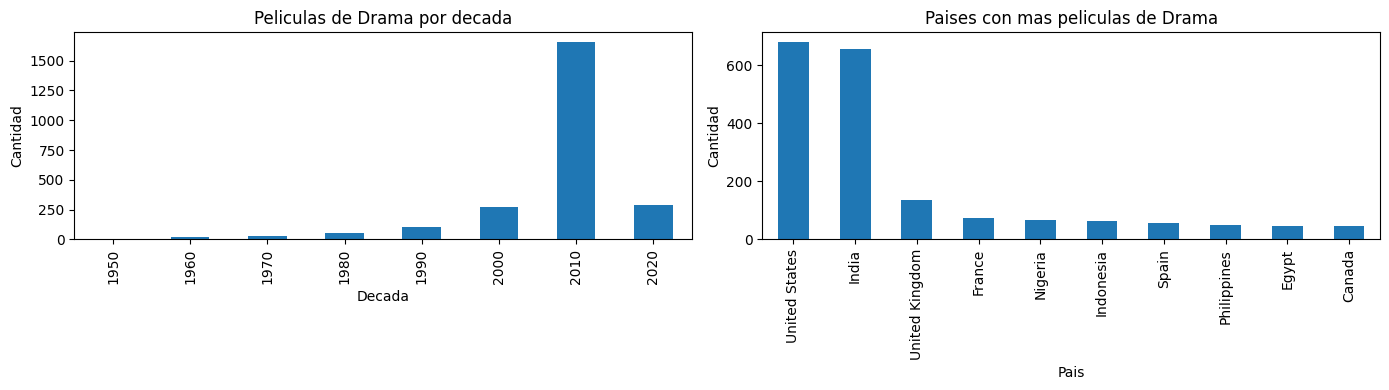

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

decada_mayor.plot(kind='bar', ax=axes[0])
axes[0].set_title(f'Peliculas de {genero_mayor_nombre} por decada')
axes[0].set_xlabel('Decada')
axes[0].set_ylabel('Cantidad')

pais_mayor.head(10).plot(kind='bar', ax=axes[1])
axes[1].set_title(f'Paises con mas peliculas de {genero_mayor_nombre}')
axes[1].set_xlabel('Pais')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

#### Consulta b

Solo se dispone del año de estreno, no de la fecha exacta. Por eso se usa el 1 de enero del año de estreno como fecha aproximada. Para producciones estrenadas antes de 2008, se usa el 1 de enero de 2008 como primera fecha posible de incorporacion al catalogo de streaming.

In [20]:
df_demora = df_generos.copy()
df_demora['fecha_base_estreno'] = pd.to_datetime(
    np.maximum(df_demora['release_year'], 2008).astype(str) + '-01-01'
)
df_demora['demora_dias'] = (df_demora['date_added'] - df_demora['fecha_base_estreno']).dt.days
df_demora['demora_anios'] = df_demora['demora_dias'] / 365.25

resumen_demora = pd.DataFrame({
    'demora_promedio_dias': [df_demora['demora_dias'].mean()],
    'demora_mediana_dias': [df_demora['demora_dias'].median()],
    'demora_promedio_anios': [df_demora['demora_anios'].mean()],
    'demora_mediana_anios': [df_demora['demora_anios'].median()]
})

resumen_demora

,demora_promedio_dias,demora_mediana_dias,demora_promedio_anios,demora_mediana_anios
0,1334.720364,578.0,3.654265,1.582478


In [21]:
demora_por_tipo = df_demora.groupby('type')[['demora_dias', 'demora_anios']].mean()
demora_por_tipo

,demora_dias,demora_anios
type,,
Movie,1543.851616,4.226835
TV Show,853.812688,2.337612


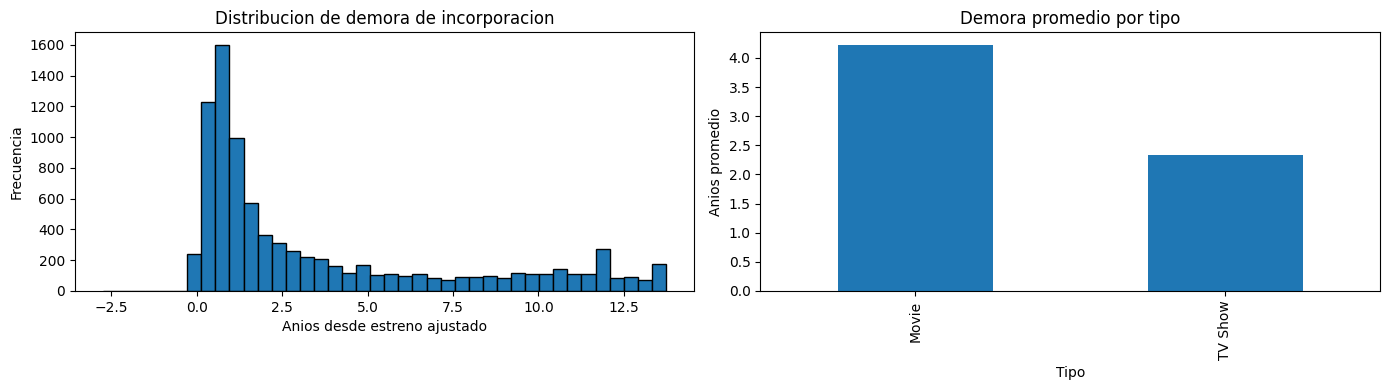

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_demora['demora_anios'].plot(kind='hist', bins=40, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribucion de demora de incorporacion')
axes[0].set_xlabel('Anios desde estreno ajustado')
axes[0].set_ylabel('Frecuencia')

demora_por_tipo['demora_anios'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Demora promedio por tipo')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Anios promedio')

plt.tight_layout()
plt.show()

#### Consulta c

Para observar cambios temporales en Horror se agrupan las producciones por decada de estreno y clasificacion por edades. Se utiliza proporcion dentro de cada decada, porque las cantidades totales de producciones no son iguales entre periodos.

In [23]:
df_horror = df_generos[df_generos['genero_Horror']].copy()

tabla_horror_rating = pd.crosstab(
    df_horror['release_decade'],
    df_horror['rating'],
    normalize='index'
)

tabla_horror_rating

rating,NR,PG,PG-13,R,TV-14,TV-MA,TV-PG
release_decade,,,,,,,
1960,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
1970,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000
1980,0.142857,0.142857,0.285714,0.142857,0.000000,0.285714,0.000000
1990,0.000000,0.000000,0.222222,0.666667,0.000000,0.111111,0.000000
2000,0.022727,0.022727,0.204545,0.431818,0.090909,0.204545,0.022727
2010,0.017182,0.000000,0.089347,0.206186,0.144330,0.529210,0.013746
2020,0.000000,0.000000,0.039474,0.105263,0.197368,0.657895,0.000000


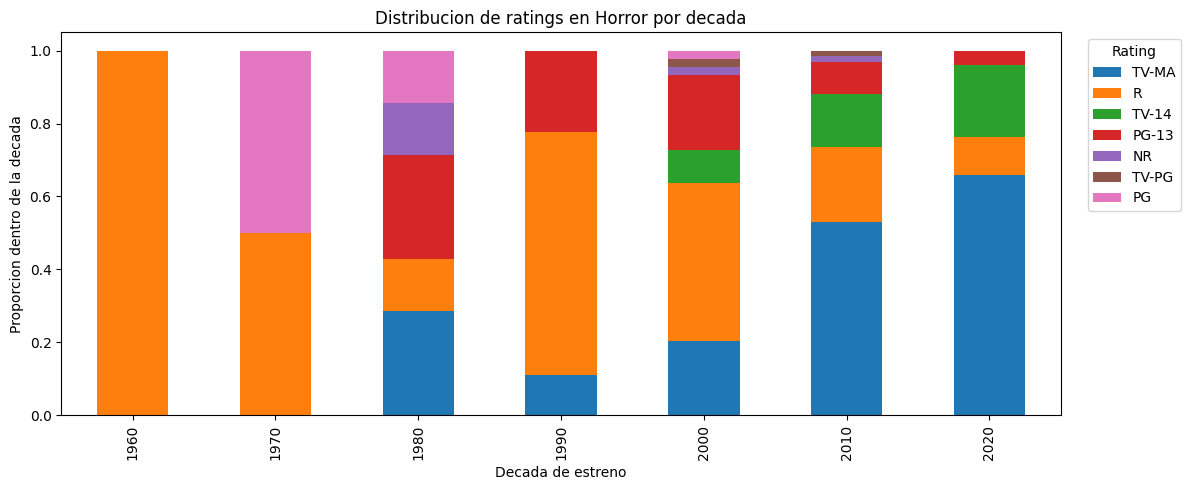

In [24]:
ratings_principales_horror = df_horror['rating'].value_counts().head(8).index
tabla_horror_plot = tabla_horror_rating[ratings_principales_horror.intersection(tabla_horror_rating.columns)]

tabla_horror_plot.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Distribucion de ratings en Horror por decada')
plt.xlabel('Decada de estreno')
plt.ylabel('Proporcion dentro de la decada')
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
conteo_horror_decada = pd.crosstab(df_horror['release_decade'], df_horror['rating'])
conteo_horror_decada

rating,NR,PG,PG-13,R,TV-14,TV-MA,TV-PG
release_decade,,,,,,,
1960,0,0,0,1,0,0,0
1970,0,2,0,2,0,0,0
1980,1,1,2,1,0,2,0
1990,0,0,2,6,0,1,0
2000,1,1,9,19,4,9,1
2010,5,0,26,60,42,154,4
2020,0,0,3,8,15,50,0


La visualizacion permite comparar la composicion de clasificaciones por edades en Horror a lo largo del tiempo. Al usar proporciones, se observa la estructura relativa de ratings sin que una decada con mas titulos domine completamente el grafico. La tabla de conteos complementa la lectura, porque una proporcion alta basada en pocos titulos debe interpretarse con cautela.

Los resultados anteriores permiten orientar una propuesta de pelicula observando que categorias tienen mayor presencia reciente, en qué decadas se concentra la produccion de ese genero, que paises aparecen con mas frecuencia y que clasificaciones por edades predominan en Horror. Estos patrones sugieren decisiones de genero, tono, clasificacion y mercado objetivo.

Sin embargo, el catalogo no mide exito. Una categoria frecuente en Netflix no necesariamente implica mayor audiencia, rentabilidad o recepcion critica. Ademas, hay informacion faltante en director y pais, la fecha de estreno se aproxima solo por anio y las categorias de genero provienen de etiquetas editoriales que pueden superponerse. Por eso, las conclusiones deben interpretarse como tendencias descriptivas del catalogo, no como garantia de exito comercial.